# <span style="color:blue">EVAC Workshop 3: Multi-objective evolution</span>

**Module leader**

Simon O'Keefe: simon.okeefe@york.ac.uk

**Graduate Teaching Assistants**

Babar Khan: bk777@york.ac.uk

Tianda Sun: tianda.sun@york.ac.uk

## <span style="color:#0073e6">Prerequisites</span>


Before participating in this practical make sure that you have watched the pre-workshop materials:
- Lecture 3
- Code walkthrough 5


# <span style="color:blue">Learning Objectives</span>

* Implement individuals with different representations to lists
* Implement and then examine multi-objective evolution
* Implement the Mu + Lamda algorithm manually, as needed for NGSA II

# <span style="color:blue">The problem: the kursawe function</span>

The Kursawe function has two objectives (see two equations below) that we want to minimize. It can have an arbirtarly number *N* of input variables *xi*, which take values within the range -5 and 5.

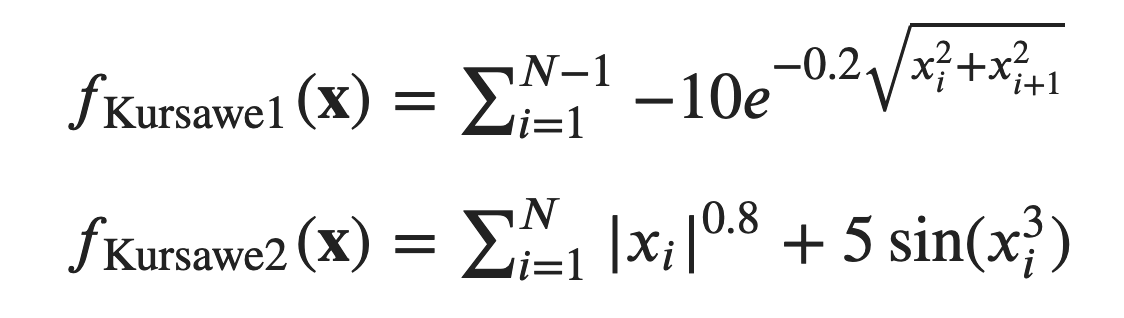

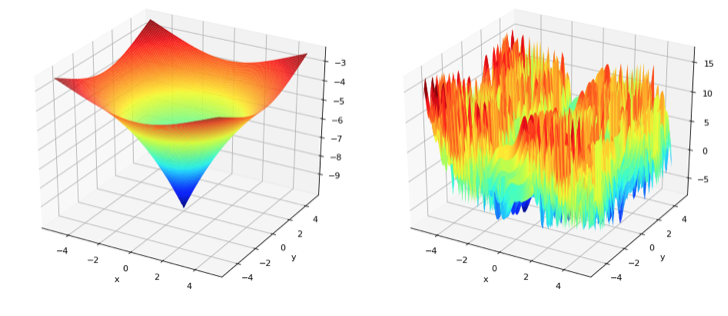

There are built-in benchmark problems in DEAP. You import them like this:

In [4]:
from deap import benchmarks

The kursawe function can be called like this:

In [5]:
exampleInputs = [-5,2,5]
benchmarks.kursawe(exampleInputs)

(-6.812092298638419, 13.935688996486114)

# <span style="color:blue">Task 1: Implement a multi objective GA for the kursawe function</span>

Create a GA that gives inputs that minimize the multi-objective function. For this, the number of inputs to use should be 3 to start with (which you can visualize). Then try changing it to 5.

## <span style="color:blue">GA Code Here</span>

In [18]:
from deap import algorithms
from deap import base
from deap import creator
from deap import tools
import random
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
IND_INIT_SIZE = 3
NGEN = 100
popSize = MU = 200
LAMBDA = 400
CXPB = 0.5
MUTPB = 0.5

def checkBounds(min, max):
    def decorator(func):
        def wrapper(*args, **kargs):
            offspring = func(*args, **kargs)
            for child in offspring:
                for i in range(len(child)):
                    if child[i] > max:
                        child[i] = max
                    elif child[i] < min:
                        child[i] = min
            return offspring
        return wrapper
    return decorator

def pareto_eq(ind1, ind2):
    return numpy.allclose(ind1[0], ind2[1])


toolbox = base.Toolbox()
creator.create("Fitness", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.Fitness)
toolbox.register("attr_item", random.uniform, -5.0, 5.0)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_item, IND_INIT_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", benchmarks.kursawe)
toolbox.register("mate", tools.cxUniform, indpb=0.1)
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.2, indpb=0.1)
toolbox.decorate("mutate", checkBounds(-5.0, 5.0))
hof = tools.ParetoFront(similar=pareto_eq)
toolbox.register("select", tools.selNSGA2)

In [8]:
pop = toolbox.population(n=popSize)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean, axis=0)
stats.register("std", numpy.std, axis=0)
stats.register("min", numpy.min, axis=0)
stats.register("max", numpy.max, axis=0)
logbook = tools.Logbook()

fitnesses = [toolbox.evaluate(i) for i in pop]
for i, f in zip(pop, fitnesses):
    i.fitness.values = f

In [ ]:
for g in range(NGEN):
    p = (g/NGEN)*100
    print((f"\r{p}"), end='')

    offspring = algorithms.varOr(pop, toolbox, LAMBDA, CXPB, MUTPB)

    invalid_inds = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = [toolbox.evaluate(ind) for ind in invalid_inds]
    for ind, fit in zip(invalid_inds, fitnesses):
        ind.fitness.values = fit

    nextGenOffspring = toolbox.select(pop + offspring, MU)
    nextGenOffspring = list(map(toolbox.clone, nextGenOffspring))
    pop[:] = nextGenOffspring

    hof.update(pop)

    record = stats.compile(pop)
    logbook.record(gen=g, **record)
print("\ndone")

9901.0000000000012
done


## <span style="color:blue">Plot the results</span>

In [10]:
%matplotlib inline

gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")

avgs_weight = [item[0] for item in avgs]
avgs_value = [item[1] for item in avgs]

Text(0, 0.5, 'Fitness (value)')

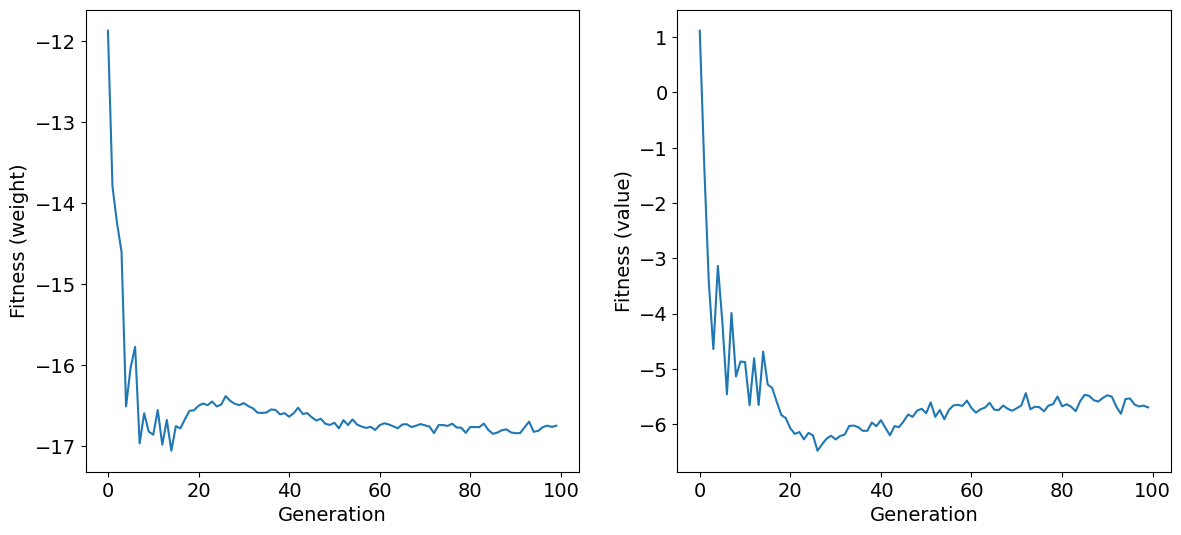

In [15]:
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
line1 = ax1.plot(gen, avgs_weight)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness (weight)")
line2 = ax2.plot(gen, avgs_value)
ax2.set_xlabel("Generation")
ax2.set_ylabel("Fitness (value)")

Be sure to plot the pareto front at the end. This is possible with the 3 arguments version of this problem. You can plot using a 3D plot in Seaborn. e.g.



You can also plot fitness in 2D using:

```sns.kdeplot(x,y)```

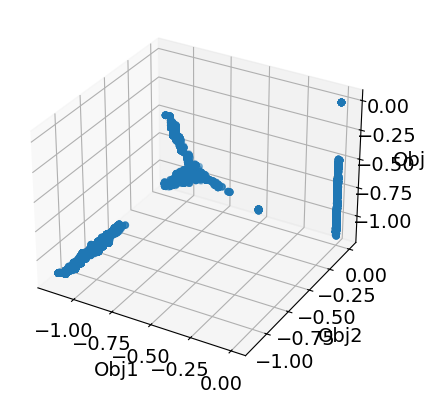

In [22]:
x = [h[0] for h in hof]
y = [h[1] for h in hof]
z = [h[2] for h in hof]

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.set_xlabel("Obj1")
ax.set_ylabel("Obj2")
ax.set_zlabel("Obj3")
ax.scatter(x, y, z)

<Axes: >

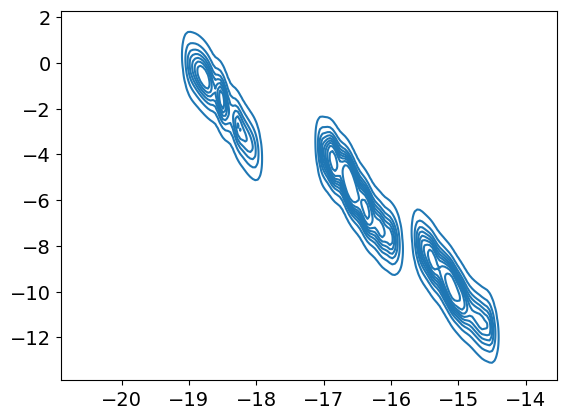

In [26]:
fitnesses = [x.fitness.values for x in hof]
x = [f[0] for f in fitnesses]
y = [f[1] for f in fitnesses]

sns.kdeplot(x=x, y=y)

# <span style="color:blue">Task 2: Manually Implement the Mu Plus Lambda Algorithm</span>

Based on the walkthough, you probably used the built-in Mu Plus Lambda algorithm from DEAP to implement your algorithm. Implementing an EA in this way is important for NGSA II because it ultimately selects from both the parent and a child population together. Mu plus Lambda is technically an **Evolutionary Strategy algorithm**, rather than a Genetic Algorithm, because children are produced before selection. This means you need to generate a child population first. For this, no selection is used. Instead we create a population of offspring by either replicating a parent, crossing over two parents, or replicating and then mutating a parent. These populations are then combined for selection.

You can read more about the MuPlusLambda algorithm here:
https://deap.readthedocs.io/en/stable/api/algo.html

To produce the offspring we can use the DEAP function algorithms.VarOR
https://deap.readthedocs.io/en/stable/api/algo.html#deap.algorithms.varOr

*(Note: The VarAnd function is also available and is a shortcut to the approach you have been manually coding before, where you perform crossover and mutation with given probabilities).*

Pseudocode for the algorithm looks like this:

evaluate(population)

for g in range(ngen):    

      offspring = varOr(population, toolbox, lambda_, cxpb, mutpb)

      evaluate(offspring)

      population = select(population + offspring, mu)

**Your task:** Implement this algorithm yourself instead of using the built-in algorithm. You will also need to update the Pareto HoF manually using hof.update(pop)

# <span style="color:blue">Optional Task 3: Implement the knapsack problem using a list or numpy array instead of set</span>

To get you more used to inheriting from different data types for individuals, **your task** is to implement the knapsack problem from the accompanying walkthrough, but represent individuals with a Python dict rather than a set.  This will also require changing the mutation and crossover functions. Allow mutation to remove items from anywhere in the bag, rather than just pop from the top.

Important: If you want to use a numpy array, you must read this first:
https://deap.readthedocs.io/en/master/tutorials/advanced/numpy.html
And for an example see this:
https://deap.readthedocs.io/en/master/examples/ga_onemax_numpy.html?highlight=numpy